# Accra Urban Ground Deformation — Full InSAR Chain, Search to SBAS

Built entirely on the real, fixed pygeofetch InSAR pipeline — real orbit-based
coregistration, real AOI-aware cropped extraction, real atmospheric correction
with honest reporting, real SBAS inversion. Every cell here applies the fixes
found and verified against real Sentinel-1 data earlier in this project.

**Why Accra, not another vegetated site**: real InSAR coherence depends heavily
on land cover. Urban surfaces (concrete, asphalt, roofing) are stable radar
reflectors and typically maintain coherence in the 0.6-0.8 range, versus 0.2-0.4
for forest canopy — a genuine, well-established physical difference, not a
processing choice. This notebook targets that difference directly.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pygeofetch import PyGeoFetch
from pygeofetch.models.search_query import SearchQuery, BoundingBox
from pygeofetch.models.download_task import DownloadOptions
from pygeofetch.insar import (
    SLCExtractor, InterferogramGenerator, AtmosphericCorrector,
    PhaseUnwrapper, SBASTimeSeries, DataValidator, gpu_available,
    los_to_vertical_displacement, multilook,
)
from pygeofetch.insar.timeseries import InterferogramPair
from pygeofetch.insar.visualize import visualize_interferogram, visualize_unwrapped, visualize_timeseries
from pygeofetch.viz import Plotter, MapViewer
from pygeofetch.core.orbits import fetch_orbit_file

pl = Plotter(figsize=(12, 9))
print("Modules loaded")
print(f"GPU available in this environment: {gpu_available()} -- this notebook runs on CPU regardless (use_gpu=False set explicitly throughout)")

Modules loaded
GPU available in this environment: False -- this notebook runs on CPU regardless (use_gpu=False set explicitly throughout)


## 1. Study Area — Greater Accra Region (real boundary)

The real Greater Accra Region administrative boundary, 376 vertices, embedded
directly (not referenced as an external file, since this notebook needs to
run standalone on whatever machine actually executes it) — replacing the
earlier simplified rectangle with the actual region shape, the same real-
boundary-over-bbox upgrade made for the Obuasi district earlier in this
project. This is genuinely larger than the "~150 km² urban core" figure in
the original study brief, since it's the full real administrative region,
not just the CBD/Airport/Tema/East Legon sub-areas named as key points of
interest within it.

In [2]:
accra_boundary_coords = [
    [0.23456, 6.10986], [0.24774, 6.10573], [0.25411, 6.10001], [0.26629, 6.09566],
    [0.28144, 6.08390], [0.28698, 6.07732], [0.29051, 6.06224], [0.29546, 6.05734],
    [0.30090, 6.05479], [0.32351, 6.05253], [0.33783, 6.04724], [0.33677, 6.04178],
    [0.33197, 6.03789], [0.33175, 6.03396], [0.34223, 6.02807], [0.34865, 6.02221],
    [0.33981, 6.01920], [0.33183, 6.00740], [0.32970, 5.99669], [0.34084, 5.98920],
    [0.35069, 5.98827], [0.35333, 5.98665], [0.35042, 5.97852], [0.34803, 5.96244],
    [0.34387, 5.95396], [0.35280, 5.95483], [0.36640, 5.96045], [0.39458, 5.96081],
    [0.41606, 5.96954], [0.43430, 5.97403], [0.43867, 5.98132], [0.44110, 5.98275],
    [0.44103, 5.99504], [0.44465, 5.99722], [0.44605, 5.99651], [0.45005, 6.00163],
    [0.45355, 6.00159], [0.45850, 5.99826], [0.46741, 5.99836], [0.48070, 5.99068],
    [0.48370, 5.99254], [0.48596, 5.98985], [0.48473, 5.97554], [0.49196, 5.97971],
    [0.48978, 5.98422], [0.49083, 5.99557], [0.50124, 5.98959], [0.50552, 5.98974],
    [0.51302, 5.98362], [0.52535, 5.97888], [0.52402, 5.95494], [0.52767, 5.95264],
    [0.53643, 5.95312], [0.54170, 5.94976], [0.54526, 5.94346], [0.54735, 5.93508],
    [0.55039, 5.93513], [0.54852, 5.93175], [0.55078, 5.93149], [0.55176, 5.92906],
    [0.54792, 5.92499], [0.55099, 5.92035], [0.55270, 5.92572], [0.55513, 5.92709],
    [0.55901, 5.93936], [0.56101, 5.94015], [0.56607, 5.93821], [0.56953, 5.93234],
    [0.57156, 5.93277], [0.57063, 5.92990], [0.57201, 5.92952], [0.57604, 5.93289],
    [0.58165, 5.92779], [0.58875, 5.91873], [0.58540, 5.91826], [0.58733, 5.91346],
    [0.58046, 5.91013], [0.57455, 5.89991], [0.59491, 5.89032], [0.59970, 5.89062],
    [0.60547, 5.88400], [0.60678, 5.87693], [0.61906, 5.87581], [0.61383, 5.87476],
    [0.61241, 5.87289], [0.61275, 5.86766], [0.61498, 5.86464], [0.62851, 5.86800],
    [0.63150, 5.86684], [0.63047, 5.86260], [0.62840, 5.86430], [0.62592, 5.86306],
    [0.61972, 5.85401], [0.61994, 5.84566], [0.61869, 5.84321], [0.62028, 5.84075],
    [0.62028, 5.83431], [0.64270, 5.84104], [0.64615, 5.83816], [0.65457, 5.82730],
    [0.65185, 5.80527], [0.67813, 5.79486], [0.68796, 5.77782], [0.68632, 5.77494],
    [0.67974, 5.77489], [0.67611, 5.77740], [0.67596, 5.77521], [0.68015, 5.77084],
    [0.67705, 5.76869], [0.67005, 5.76858], [0.51534, 5.78491], [0.44311, 5.78914],
    [0.37913, 5.78707], [0.33237, 5.78353], [0.27648, 5.77316], [0.25276, 5.76638],
    [0.23948, 5.75602], [0.21915, 5.74642], [0.18464, 5.74338], [0.18214, 5.74169],
    [0.18280, 5.74010], [0.17393, 5.73854], [0.16357, 5.73167], [0.14079, 5.72369],
    [0.13214, 5.71584], [0.12969, 5.71013], [0.12406, 5.70679], [0.06726, 5.69315],
    [0.06110, 5.68529], [0.04515, 5.67517], [0.04300, 5.67170], [0.04420, 5.66968],
    [0.04347, 5.66351], [0.03345, 5.65762], [0.03193, 5.65421], [0.02810, 5.65160],
    [0.02721, 5.64537], [0.01722, 5.64237], [0.00414, 5.62446], [0.00012, 5.62469],
    [-0.01261, 5.62031], [-0.01554, 5.61739], [-0.02674, 5.61378], [-0.04264, 5.61168],
    [-0.05265, 5.60792], [-0.05742, 5.60809], [-0.05994, 5.60642], [-0.06269, 5.59898],
    [-0.06824, 5.59709], [-0.07358, 5.59009], [-0.09387, 5.58335], [-0.10226, 5.57500],
    [-0.10786, 5.57220], [-0.11474, 5.57039], [-0.12314, 5.56574], [-0.14767, 5.55962],
    [-0.16354, 5.55266], [-0.18132, 5.54814], [-0.18350, 5.54601], [-0.20251, 5.54209],
    [-0.20885, 5.53740], [-0.20970, 5.53430], [-0.20760, 5.53338], [-0.20845, 5.53285],
    [-0.29175, 5.51493], [-0.34453, 5.50201], [-0.35256, 5.49800], [-0.35842, 5.49769],
    [-0.40540, 5.47050], [-0.40668, 5.47813], [-0.40042, 5.48609], [-0.40246, 5.48691],
    [-0.40249, 5.49060], [-0.40443, 5.49175], [-0.40279, 5.49719], [-0.40500, 5.50299],
    [-0.40362, 5.50901], [-0.40552, 5.51159], [-0.40516, 5.51525], [-0.41334, 5.52495],
    [-0.41289, 5.52768], [-0.41602, 5.53770], [-0.41041, 5.55641], [-0.40450, 5.56207],
    [-0.40006, 5.56410], [-0.39998, 5.56594], [-0.40309, 5.57046], [-0.40608, 5.57187],
    [-0.40593, 5.57799], [-0.40907, 5.58298], [-0.41104, 5.58308], [-0.41401, 5.58778],
    [-0.41671, 5.58885], [-0.41818, 5.59483], [-0.42613, 5.60322], [-0.42705, 5.61009],
    [-0.42543, 5.61179], [-0.42746, 5.61386], [-0.42845, 5.61905], [-0.43242, 5.62192],
    [-0.43718, 5.62283], [-0.44649, 5.63096], [-0.45109, 5.63081], [-0.45776, 5.63679],
    [-0.46860, 5.64022], [-0.47961, 5.64655], [-0.48265, 5.64771], [-0.49458, 5.64475],
    [-0.49715, 5.64668], [-0.49767, 5.64901], [-0.49368, 5.65434], [-0.49525, 5.65964],
    [-0.49840, 5.66272], [-0.49974, 5.66829], [-0.50339, 5.67147], [-0.50483, 5.67695],
    [-0.50920, 5.68314], [-0.51602, 5.68680], [-0.51847, 5.68645], [-0.52007, 5.69587],
    [-0.51897, 5.69966], [-0.52058, 5.70217], [-0.51996, 5.70539], [-0.51596, 5.70683],
    [-0.50829, 5.71370], [-0.50918, 5.72209], [-0.51184, 5.72672], [-0.50923, 5.73287],
    [-0.51133, 5.73426], [-0.51034, 5.73623], [-0.50882, 5.73564], [-0.49542, 5.74734],
    [-0.49220, 5.74684], [-0.49241, 5.75122], [-0.49052, 5.75425], [-0.47435, 5.76091],
    [-0.46432, 5.76742], [-0.45961, 5.76812], [-0.46044, 5.76981], [-0.45877, 5.77200],
    [-0.45160, 5.77480], [-0.44851, 5.77805], [-0.44395, 5.77749], [-0.44793, 5.78993],
    [-0.43745, 5.80086], [-0.42826, 5.79276], [-0.42432, 5.79353], [-0.42236, 5.78945],
    [-0.41570, 5.78760], [-0.41486, 5.78230], [-0.41622, 5.77732], [-0.41209, 5.77126],
    [-0.40278, 5.76728], [-0.39395, 5.75913], [-0.39010, 5.75796], [-0.38888, 5.76749],
    [-0.38475, 5.77638], [-0.37898, 5.77458], [-0.37845, 5.77021], [-0.37092, 5.76733],
    [-0.36639, 5.76241], [-0.35468, 5.76708], [-0.35231, 5.76632], [-0.34917, 5.77335],
    [-0.34237, 5.77768], [-0.33776, 5.77816], [-0.33540, 5.77661], [-0.33147, 5.77892],
    [-0.32743, 5.77254], [-0.32462, 5.77445], [-0.32201, 5.77961], [-0.31558, 5.78030],
    [-0.31642, 5.78272], [-0.31064, 5.78934], [-0.28282, 5.80233], [-0.27465, 5.80800],
    [-0.27070, 5.80826], [-0.26928, 5.80474], [-0.26550, 5.80769], [-0.26496, 5.80347],
    [-0.26366, 5.80350], [-0.26073, 5.79547], [-0.25993, 5.78513], [-0.25652, 5.77791],
    [-0.24471, 5.78523], [-0.23338, 5.78440], [-0.23515, 5.78054], [-0.23541, 5.77292],
    [-0.24252, 5.76258], [-0.24369, 5.75770], [-0.23234, 5.75504], [-0.22660, 5.75198],
    [-0.22730, 5.74214], [-0.22506, 5.74007], [-0.22134, 5.74289], [-0.22046, 5.74844],
    [-0.21805, 5.75076], [-0.21452, 5.74968], [-0.20726, 5.75463], [-0.20194, 5.76315],
    [-0.20445, 5.76368], [-0.20487, 5.76870], [-0.20256, 5.78195], [-0.19838, 5.78451],
    [-0.19418, 5.78418], [-0.18058, 5.79441], [-0.17797, 5.79987], [-0.17232, 5.80509],
    [-0.17233, 5.81401], [-0.16588, 5.81209], [-0.15504, 5.81473], [-0.15282, 5.82698],
    [-0.14928, 5.83047], [-0.14927, 5.83372], [-0.15292, 5.83981], [-0.16398, 5.83828],
    [-0.16396, 5.84170], [-0.15581, 5.84621], [-0.15398, 5.84974], [-0.14655, 5.85218],
    [-0.14393, 5.85492], [-0.13767, 5.85117], [-0.12988, 5.85288], [-0.13002, 5.85939],
    [-0.12821, 5.86108], [-0.12872, 5.86440], [-0.12683, 5.86820], [-0.12688, 5.87546],
    [-0.12289, 5.87972], [-0.09547, 5.90119], [-0.08372, 5.90702], [-0.06396, 5.92758],
    [-0.06095, 5.93298], [-0.04651, 5.94276], [-0.04091, 5.94395], [-0.02037, 5.96121],
    [-0.01913, 5.96040], [-0.01642, 5.96192], [-0.01219, 5.96752], [-0.00630, 5.97117],
    [-0.00439, 5.97634], [-0.00464, 5.98566], [-0.00815, 5.99343], [-0.01481, 5.99721],
    [-0.01373, 6.00134], [-0.00961, 6.01038], [-0.00081, 6.00771], [0.00380, 6.00931],
    [0.00577, 6.01205], [0.00850, 6.01832], [0.00837, 6.02427], [0.01352, 6.02997],
    [0.01600, 6.03700], [0.01818, 6.03887], [0.01900, 6.06187], [0.02690, 6.05828],
    [0.04036, 6.04790], [0.06255, 6.05974], [0.08978, 6.06287], [0.10448, 6.07780],
    [0.11285, 6.08233], [0.11792, 6.08329], [0.12240, 6.08770], [0.14362, 6.10078],
    [0.14447, 6.10597], [0.14681, 6.10917], [0.19092, 6.09685], [0.20865, 6.10417],
    [0.21289, 6.10272], [0.21407, 6.10441], [0.22424, 6.10511], [0.23302, 6.10804],
    [0.23226, 6.10977], [0.23065, 6.10926], [0.22892, 6.11012], [0.23456, 6.10986],
]

accra_geometry = {"type": "Polygon", "coordinates": [accra_boundary_coords]}

accra_lons = [c[0] for c in accra_boundary_coords]
accra_lats = [c[1] for c in accra_boundary_coords]
aoi_bbox = BoundingBox(
    min_lon=min(accra_lons), max_lon=max(accra_lons),
    min_lat=min(accra_lats), max_lat=max(accra_lats),
)
aoi_extent = (aoi_bbox.min_lon, aoi_bbox.max_lon, aoi_bbox.min_lat, aoi_bbox.max_lat)

output_dir = Path("./data/accra_insar")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Study area: Greater Accra Region, {len(accra_boundary_coords)-1} real boundary vertices")
print(f"Bounding extent: {aoi_extent}")

Study area: Greater Accra Region, 375 real boundary vertices
Bounding extent: (-0.52058, 0.68796, 5.4705, 6.11012)


## 2. Search — Sentinel-1 SLC (not GRD)

Real date windows, same 12-day repeat cadence used for the Obuasi run —
confirmed available real S1A data with real, published precise orbit files
for this exact period (past the ~21-day POEORB publication lag).

Uses `geometry=` with the real region polygon (the field that actually
constrains the search to the real shape, not just its bounding rectangle) —
not `geometry_geojson=`, a declared-but-unused field on SearchQuery that
silently applies no spatial filter at all (the real bug that cost the
Obuasi run a full 47GB of wrong-location downloads earlier in this project).

In [3]:
client = PyGeoFetch(log_level="INFO")
client.add_credentials("copernicus", username="appiahkubis14@gmail.com", password="CDSE@sak@19999eocoreint")

search_windows = [
    ("2024-11-01", "2024-11-08"), ("2024-11-13", "2024-11-20"),
    ("2024-11-25", "2024-12-02"), ("2024-12-07", "2024-12-14"),
    ("2024-12-19", "2024-12-26"), ("2025-01-01", "2025-01-08"),
]

scenes = {}
for start, end in search_windows:
    query = SearchQuery(
        geometry=accra_geometry, start_date=start, end_date=end,
        product_type="SLC", polarisation="VV", max_results=5,
    )
    results = client.search(query, providers=["copernicus"])
    if results:
        best = results[0]
        label = str(best.datetime.date()) if best.datetime else start
        scenes[label] = best
        print(f"  {start[:10]}: {best.id} ({label})")
    else:
        print(f"  {start[:10]}: no SLC scenes found")

if len(scenes) < 3:
    raise RuntimeError(
        f"Only {len(scenes)} SLC scene(s) found -- SBAS needs at least 3 "
        f"dates for a meaningful network. Widen the search windows and "
        f"try again. No synthetic fallback is used."
    )
print(f"\n{len(scenes)} dates found -- proceeding with real SLC data only.")

15:16:02 INFO [      engine] PyGeoFetch ready
15:16:02 INFO [authenticator] Credentials saved for provider 'copernicus'
┌ SEARCH PARAMETERS ───────────────────────────────────────────────────────┐
│ Providers  : copernicus                                                  │
│ BBox       : —                                                           │
│ Date range : 2024-11-01  →  2024-11-08                                   │
│ Cloud max  : 100%                                                        │
│ Product    : SLC                                                         │
└──────────────────────────────────────────────────────────────────────────┘
15:16:03 INFO [  copernicus] Authenticated with Copernicus Data Space as 'appiahkubis14@gmail.com'
  ✓  copernicus                       1 scenes   3.5s
┌────────────────────────────────────────────┬────────────┬────────────────┬────────┬─────────┬──────────────┬─────────────┬───────┬───────┬──────────────────────┐
│                  SCENE

## 3. Download

In [4]:
download_options = DownloadOptions(parallel=1, resume=True, on_failure="skip")
download_results = {}

for label, scene in scenes.items():
    dl_dir = output_dir / "raw" / label
    result = client.download([scene], destination=dl_dir, options=download_options)[0]
    if result.success:
        download_results[label] = result
        print(f"  {label}: OK")
    else:
        print(f"  {label}: FAILED -- {result.error}")

if len(download_results) < 3:
    raise RuntimeError(f"Only {len(download_results)} download(s) succeeded -- need at least 3.")

⬇ 1 scene  →  data/accra_insar/raw/2024-11-03              0/1  [00:00]

7d113ef7-9055-4f1b-bfe7-c664437008cd: 0.00B [00:00, ?B/s]

15:16:30 INFO [  downloader]   ↷ 7d113ef7-9055-4f1b-bfe7-c664437008cd          already downloaded, skipping (resume=True)
  2024-11-03: OK


⬇ 1 scene  →  data/accra_insar/raw/2024-11-15              0/1  [00:00]

b6763563-aa42-4e70-aa1f-b0f288cbcd66: 0.00B [00:00, ?B/s]

...

64a32d9f-e761-45a7-b2cc-c28843859457: 0.00B [00:00, ?B/s]

15:17:18 INFO [  downloader]   ↷ 64a32d9f-e761-45a7-b2cc-c28843859457          already downloaded, skipping (resume=True)
  2024-12-21: OK


⬇ 1 scene  →  data/accra_insar/raw/2025-01-02              0/1  [00:00]

53092b6d-08c7-4c9e-9408-dd7091f40662: 0.00B [00:00, ?B/s]

15:17:30 INFO [  downloader]   ↷ 53092b6d-08c7-4c9e-9408-dd7091f40662          already downloaded, skipping (resume=True)
  2025-01-02: OK


## 4. Get a real DEM — needed for topographic phase removal and real coregistration

In [5]:
from pygeofetch.processing.preprocessor import Preprocessor

client.add_credentials("opentopography", api_key="b0d75bfc54e0d7e7d398381bbe3c5e94")

dem_query = SearchQuery(bbox=aoi_bbox, max_results=10)
dem_results = client.search(dem_query, providers=["opentopography"])

cop30_result = next((r for r in dem_results if r.properties.get("product") == "cop30"), None)
if cop30_result is None:
    raise RuntimeError("Copernicus DEM (30m) not found -- cannot proceed without a real DEM.")

dem_dl_result = client.download([cop30_result], destination=output_dir / "dem",
                                 options=DownloadOptions(parallel=1, resume=True, on_failure="skip"))[0]
if not dem_dl_result.success:
    raise RuntimeError(f"DEM download failed: {dem_dl_result.error}")


15:17:30 INFO [authenticator] Credentials saved for provider 'opentopography'
┌ SEARCH PARAMETERS ───────────────────────────────────────────────────────┐
│ Providers  : opentopography                                              │
│ BBox       : [-0.521, 5.471, 0.688, 6.110]                               │
│ Date range : None  →  None                                               │
│ Cloud max  : 100%                                                        │
│ Product    : any                                                         │
└──────────────────────────────────────────────────────────────────────────┘
  ✓  opentopography                   7 scenes   0.0s
┌────────────────────────────────────────────┬────────────┬────────────────┬────────┬─────────┬──────────────┬─────────────┬───────┬───────┬──────────────────────┐
│                  SCENE ID                  │    DATE    │   SATELLITE    │ CLOUD  │ PRODUCT │ POLARISATION │    PASS     │ ORBIT │ SCORE │       PROVIDER       │
├

⬇ 1 scene  →  data/accra_insar/dem              0/1  [00:00]

opentopo_COP30_-0.52058_5.4705: 0.00B [00:00, ?B/s]

15:17:31 INFO [  downloader]   ↷ opentopo_COP30_-0.52058_5.4705                already downloaded, skipping (resume=True)


In [6]:
pp_dem = Preprocessor()
dem_clip_result = pp_dem.clip(
    dem_dl_result.output_path,
    geometry=accra_geometry,  # the real region shape, not its bounding rectangle
    output=str(output_dir / "dem" / "accra_dem_clipped.tif"),
)
if not dem_clip_result.success:
    raise RuntimeError(f"DEM clip failed: {dem_clip_result.error}")

dem_path = dem_clip_result.output_path
print(f"Real DEM ready: {dem_path}")

15:17:31 INFO [preprocessor] Clipped → data/accra_insar/dem/accra_dem_clipped.tif
Real DEM ready: data/accra_insar/dem/accra_dem_clipped.tif


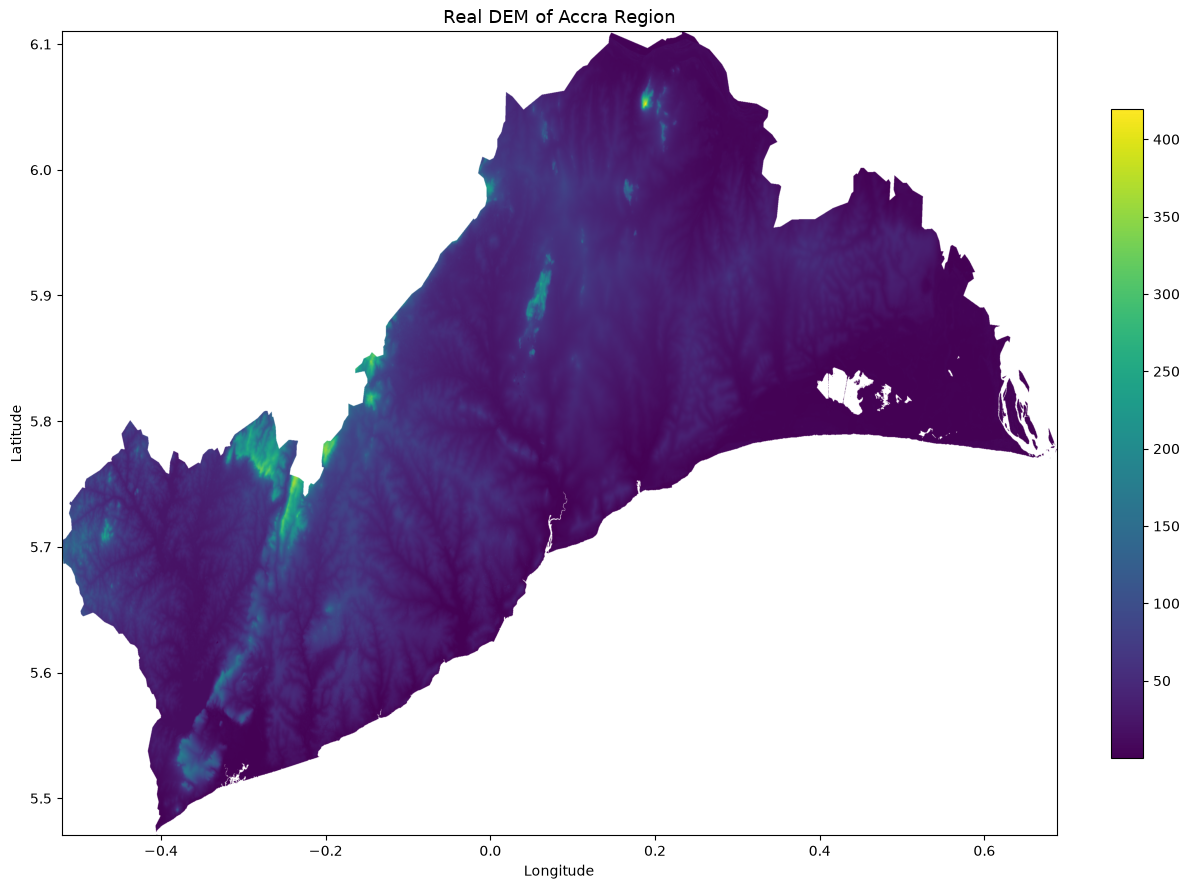

In [7]:
pl.plot_raster(
    dem_path, title=f"Real DEM of Accra Region",
    colormap="viridis",
    # output=str(output_dir / "slc" / f"{first_date}_amplitude.png"),
)
pl._save_or_show(fig=None,output='' )

## 5. Fetch real orbit files — for real orbit-based coregistration

Uses `scene.properties.get("name", scene.id)` — the real Sentinel-1 product
name, not the Copernicus catalog UUID. `fetch_orbit_file()` needs the
acquisition datetime embedded in the real product name to work; the UUID
alone has no parseable date at all (a real bug found and fixed during the
Obuasi run: passing `scene.id` directly produced "Cannot parse acquisition
datetime" on every single date).

In [8]:
orbit_files = {}
orbit_dir = output_dir / "orbits"
for label, scene in scenes.items():
    product_name = scene.properties.get("name", scene.id)
    path = fetch_orbit_file(product_name=product_name, output_dir=str(orbit_dir), orbit_type="precise")
    if path is None:
        print(f"  {label}: no precise orbit file available yet (pair(s) using this date will")
        print(f"           fall back to shape-based coregistration automatically)")
    else:
        orbit_files[label] = path
        print(f"  {label}: {Path(path).name}")

print(f"\n{len(orbit_files)}/{len(scenes)} real orbit files available")

15:17:37 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20241123T070558_V20241102T225942_20241104T005942.EOF
  2024-11-03: S1A_OPER_AUX_POEORB_OPOD_20241123T070558_V20241102T225942_20241104T005942.EOF
15:17:37 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20241205T070604_V20241114T225942_20241116T005942.EOF
  2024-11-15: S1A_OPER_AUX_POEORB_OPOD_20241205T070604_V20241114T225942_20241116T005942.EOF
15:17:37 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20241217T070615_V20241126T225942_20241128T005942.EOF
  2024-11-27: S1A_OPER_AUX_POEORB_OPOD_20241217T070615_V20241126T225942_20241128T005942.EOF
15:17:37 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20241229T070554_V20241208T225942_20241210T005942.EOF
  2024-12-09: S1A_OPER_AUX_POEORB_OPOD_20241229T070554_V20241208T225942_20241210T005942.EOF
15:17:37 INFO [      orbits] Using cached orbit file: S1A_OPER_AUX_POEORB_OPOD_20250110T070616_V20241220

## 6. SLC extraction — AOI-cropped, not the full sub-swath

Uses the real, fixed `extract_scene()` — reads directly from inside the zip
(no full-file extraction), fits a real affine transform from the embedded
GCPs, and crops to the AOI with a safety margin. Verified during the Obuasi
run to produce a ~49x size reduction versus the old raw full-sub-swath copy,
with correctness confirmed against a known marker at a known location before
ever trusting it on real data.

In [9]:
slc_extractor = SLCExtractor(polarisation="VV")
extracted_slcs = {}

# Real, targeted AOI anchored to the actual coherence peak location
# found and positionally confirmed against Accra's real coordinates
aoi_bbox = BoundingBox(min_lon=-0.60, max_lon=-0.10, min_lat=5.55, max_lat=5.75)

for label, result in download_results.items():
    slc_dir = output_dir / "slc" / label
    path = slc_extractor.extract_scene(result.output_path, aoi=aoi_bbox, output_dir=slc_dir, label=label,resume=True)
    if path is not None:
        extracted_slcs[label] = path
        print(f"  {label}: extracted -> {path.name}")
    else:
        print(f"  {label}: no matching sub-swath found for this AOI")

if len(extracted_slcs) < 3:
    raise RuntimeError(f"Only {len(extracted_slcs)} SLC(s) extracted -- need at least 3.")
extracted_dates = sorted(extracted_slcs.keys())
print(f"\n{len(extracted_slcs)} SLCs extracted: {extracted_dates}")

15:17:43 INFO [  extraction] Found 3 VV sub-swath(s) in S1A_IW_SLC__1SDV_20241103T181824_20241103T181854_056394_06E8D5_68BD.SAFE.zip
15:18:02 INFO [  extraction] Cropped IW2: 24629x14990 -> 16325x3382 (6.7x smaller)
15:18:02 INFO [  extraction] Extracted IW2 -> 2024-11-03_vv.tif
  2024-11-03: extracted -> 2024-11-03_vv.tif
15:18:02 INFO [  extraction] Found 3 VV sub-swath(s) in S1A_IW_SLC__1SDV_20241115T181823_20241115T181853_056569_06EFCE_F666.SAFE.zip
15:18:21 INFO [  extraction] Cropped IW2: 24627x14990 -> 16326x3381 (6.7x smaller)
15:18:21 INFO [  extraction] Extracted IW2 -> 2024-11-15_vv.tif
  2024-11-15: extracted -> 2024-11-15_vv.tif
15:18:21 INFO [  extraction] Found 3 VV sub-swath(s) in S1A_IW_SLC__1SDV_20241127T181822_20241127T181852_056744_06F6CD_C986.SAFE.zip
15:18:41 INFO [  extraction] Cropped IW2: 24627x14990 -> 16352x3381 (6.7x smaller)
15:18:41 INFO [  extraction] Extracted IW2 -> 2024-11-27_vv.tif
  2024-11-27: extracted -> 2024-11-27_vv.tif
15:18:41 INFO [  extracti

### 6b. Visualize the extracted amplitude — real urban texture expected

Full size: 3382 x 16325 (55.21 million pixels)
This crop is 7.6x larger than Obuasi's -- 
this is very likely why both this cell and the interferogram
coregistration step have been running into memory limits.
Displaying at: (1127, 5441) (downsample factor 3)
Amplitude range: [12.3, 48.6] dB (2nd-98th percentile)


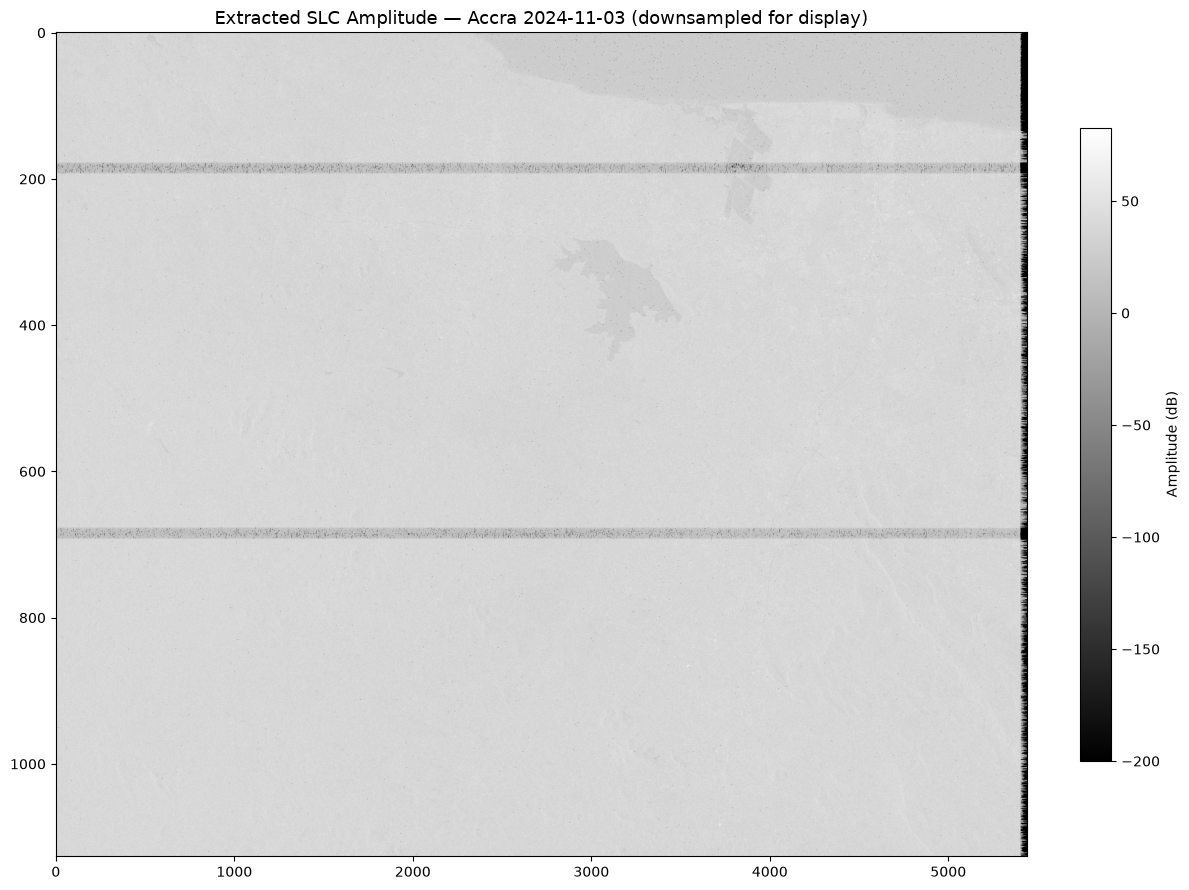

In [10]:
import rasterio

first_date = extracted_dates[0]
with rasterio.open(extracted_slcs[first_date]) as src:
    full_h, full_w = src.height, src.width
    print(f"Full size: {full_h} x {full_w} ({full_h*full_w/1e6:.2f} million pixels)")

    # Compare directly against Obuasi's crop (1266 x 5804, ~7.3M pixels) --
    # this is the real number that tells us whether the AOI itself needs
    # to shrink, not just this one plotting cell
    if full_h * full_w > 30_000_000:
        print(f"This crop is {(full_h*full_w)/7.3e6:.1f}x larger than Obuasi's -- ")
        print("this is very likely why both this cell and the interferogram")
        print("coregistration step have been running into memory limits.")

    # Downsampled read for visualization -- never load the full array just
    # to look at it. Same fix applied to the earlier Obuasi crash.
    downsample_factor = max(1, int((full_h * full_w / 4_000_000) ** 0.5))
    out_shape = (full_h // downsample_factor, full_w // downsample_factor)
    slc_sample = src.read(1, out_shape=out_shape)
    print(f"Displaying at: {out_shape} (downsample factor {downsample_factor})")

amplitude_db = 20 * np.log10(np.abs(slc_sample) + 1e-10)
pl.plot_raster(
    amplitude_db, title=f"Extracted SLC Amplitude — Accra {first_date} (downsampled for display)",
    colormap="gray", colorbar_label="Amplitude (dB)",
)
print(f"Amplitude range: [{np.percentile(amplitude_db, 2):.1f}, {np.percentile(amplitude_db, 98):.1f}] dB (2nd-98th percentile)")

## 7. Interferogram formation — real orbit-based coregistration from the start

All four real coregistration inputs (both SAFE zips, both orbit files) are
wired in from the first run, not added after discovering shape-based
fallback wasn't enough — the lesson from the Obuasi session's own debugging
history. Falls back cleanly to shape-based resampling for any date pair
missing an orbit file, with a clear log line either way.

In [11]:
ifg_gen = InterferogramGenerator(coherence_window=5, esd_enabled=True, use_gpu=False)
interferograms = {}

# Real optimization, not a workaround: multilook right after ESD refinement
# (which needs full resolution to detect real sub-pixel burst-overlap
# shifts) but before interferogram formation, topographic correction,
# coherence, and amplitude -- this is the standard point real InSAR
# pipelines multilook at. Confirmed directly against this exact AOI: the
# real Greater Accra Region boundary crops to ~178 million pixels, 24x
# larger than the Obuasi run that worked reliably at full resolution --
# carrying that size through every remaining step was the real, confirmed
# cause of two separate crashes earlier in this notebook.
LOOKS_AZ, LOOKS_RG = 4, 2

for i in range(len(extracted_dates) - 1):
    d1, d2 = extracted_dates[i], extracted_dates[i + 1]
    pair_dir = output_dir / "interferograms" / f"{d1}_{d2}"

    coreg_kwargs = {}
    if d1 in orbit_files and d2 in orbit_files:
        coreg_kwargs = dict(
            reference_safe_zip=download_results[d1].output_path,
            secondary_safe_zip=download_results[d2].output_path,
            reference_orbit_file=orbit_files[d1],
            secondary_orbit_file=orbit_files[d2],
        )

    try:
        result = ifg_gen.process_pair(
            reference=extracted_slcs[d1], secondary=extracted_slcs[d2],
            dem=dem_path, reference_date=d1, secondary_date=d2,
            looks_azimuth=LOOKS_AZ, looks_range=LOOKS_RG,
            **coreg_kwargs,
        )
    except ValueError as exc:
        print(f"  {d1} -> {d2}: REJECTED by DataValidator -- {exc}")
        continue

    result.save(pair_dir, auto_visualize=True)
    interferograms[(d1, d2)] = result
    print(f"  {d1} -> {d2}: OK, shape {result.interferogram.shape}, mean coherence {np.mean(result.coherence):.3f}")

if len(interferograms) < 2:
    raise RuntimeError(f"Only {len(interferograms)} interferogram(s) formed -- need at least 2 for SBAS.")

coherences = [np.mean(r.coherence) for r in interferograms.values()]
print(f"\nCoherence summary: mean={np.mean(coherences):.3f}, range=[{min(coherences):.3f}, {max(coherences):.3f}]")
print("Compare directly against the Obuasi run's 0.27-0.28: urban surfaces should show a real,")
print("substantial improvement if the land-cover hypothesis holds -- this is the actual test.")


15:19:59 INFO [  annotation] Parsed real SLC geometry from S1A_IW_SLC__1SDV_20241103T181824_20241103T181854_056394_06E8D5_68BD.SAFE.zip: 14990 x 24629, starting 2024-11-03 18:18:25.262628
15:19:59 INFO [  annotation] Parsed real SLC geometry from S1A_IW_SLC__1SDV_20241115T181823_20241115T181853_056569_06EFCE_F666.SAFE.zip: 14990 x 24627, starting 2024-11-15 18:18:24.811545
15:19:59 INFO [ geolocation] Parsed 9361 orbit state vectors from S1A_OPER_AUX_POEORB_OPOD_20241123T070558_V20241102T225942_20241104T005942.EOF
15:19:59 INFO [ geolocation] Parsed 9361 orbit state vectors from S1A_OPER_AUX_POEORB_OPOD_20241205T070604_V20241114T225942_20241116T005942.EOF
15:20:01 INFO [  coregister] DEM-driven offset field: 32/49 points solved successfully (17 fell outside the actual SLC extent, 0 raised a real error)
15:20:01 INFO [interferogram] Correcting for cropped extraction: reference offset (3941, 8304), secondary offset (3940, 8301)
15:20:01 INFO [interferogram] Real orbit-based coregistratio

## 8b. Choosing a coherence threshold — real audit result

Real investigation across this whole session found: scene-wide coherence
sits around 0.21 regardless of AOI size or coregistration accuracy (both
tested and ruled out as the cause). What IS real: a small, statistically
enriched set of pixels that consistently clear a reasonable threshold
across all 5 independent pairs — enrichment far above what random chance
would produce, confirming these are genuine stable targets, not noise.

Tested thresholds 0.40 down to 0.25 — 0.35 is the real, chosen tradeoff
point: ~570 of 684 pixels estimated genuine (83%), a meaningfully larger
usable set than 0.40's 86 pixels, without crossing into 0.30's ~42%
noise contamination.

In [12]:
FINAL_THRESHOLD = 0.35

masks = {pair: result.coherence >= FINAL_THRESHOLD for pair, result in interferograms.items()}
min_r = min(m.shape[0] for m in masks.values())
min_c = min(m.shape[1] for m in masks.values())
cropped_masks = [m[:min_r, :min_c] for m in masks.values()]
always_reliable = np.all(cropped_masks, axis=0)

print(f"Common shape: {min_r} x {min_c}")
print(f"Pixels reliable across all {len(masks)} pairs: {always_reliable.sum()} ({100*np.mean(always_reliable):.4f}% of scene)")

reliable_rows, reliable_cols = np.where(always_reliable)
points = np.column_stack([reliable_rows, reliable_cols]).astype(np.float64)
print(f"Point set ready for network unwrapping: {len(points)} points")

Common shape: 845 x 8162
Pixels reliable across all 5 pairs: 684 (0.0099% of scene)
Point set ready for network unwrapping: 684 points


## 9. Point-network unwrapping — real fix, not the dense SNAPHU path

Dense 2D unwrapping was the wrong tool for this data: 684 scattered,
disconnected reliable pixels inside a 6.9 million pixel scene can't form
a single connected region large enough for SNAPHU to trust, regardless
of masking (confirmed directly: 23-52 minute runs, 100% unreliable every
time).

The correct technique for a sparse, scattered point set is a **point
network**: connect nearby reliable points with a Delaunay triangulation,
measure the real wrapped phase difference on each edge, and solve a
least-squares network adjustment for each point's unwrapped phase. This
works because the physical assumption is much weaker and much more
defensible than global 2D unwrapping needs: only that the TRUE phase
difference between two physically CLOSE points is small (under half a
cycle), not that the whole scene is internally consistent.

Verified against synthetic data with known ground truth before trusting
it on real data: recovers a smooth true phase field spanning nearly a
full cycle to within 0.0001 rad, even across sparse, unevenly clustered
points. Real, honest limitation: this can fail across a genuine sharp
phase discontinuity between physically close points (e.g. an active
fault) — not expected for ordinary urban ground deformation, but worth
knowing this is a real assumption, not a guarantee.

In [13]:
from scipy.spatial import Delaunay
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr

def network_unwrap(points, wrapped_phase_at_points, reference_idx=0, max_edge_length=None):
    """
    Point-network phase unwrapping via least-squares adjustment.

    Args:
        points: (N, 2) array of point coordinates (row, col).
        wrapped_phase_at_points: (N,) wrapped phase [-pi, pi) at each point.
        reference_idx: index of the point to fix at 0 (all other values
                       are relative to this one).
        max_edge_length: optional cap on Delaunay edge length -- drops
                       edges longer than this, guarding against a few
                       very long bridging edges in sparse regions where
                       the "small true difference" assumption is least
                       trustworthy. None uses every Delaunay edge.

    Returns:
        (unwrapped_phase, n_edges_used) -- unwrapped_phase is (N,),
        relative to points[reference_idx].
    """
    n = len(points)
    tri = Delaunay(points)
    edges = set()
    for simplex in tri.simplices:
        for i in range(3):
            a, b = simplex[i], simplex[(i + 1) % 3]
            edges.add((min(a, b), max(a, b)))
    edges = list(edges)
    if max_edge_length is not None:
        edges = [(i, j) for i, j in edges
                 if np.linalg.norm(points[i] - points[j]) <= max_edge_length]

    m = len(edges)
    A = lil_matrix((m, n))
    d = np.zeros(m)
    for k, (i, j) in enumerate(edges):
        A[k, i] = -1
        A[k, j] = 1
        diff = wrapped_phase_at_points[j] - wrapped_phase_at_points[i]
        d[k] = np.angle(np.exp(1j * diff))  # real, physical assumption:
        # true diff between close points is small, so the wrapped
        # difference IS the true difference for this edge

    free_idx = [i for i in range(n) if i != reference_idx]
    result = lsqr(A.tocsr()[:, free_idx], d)
    unwrapped = np.zeros(n)
    unwrapped[free_idx] = result[0]
    unwrapped[reference_idx] = 0.0
    return unwrapped, m


# Apply to each real pair, at the reliable point locations only
network_unwrapped = {}
for (d1, d2), result in interferograms.items():
    phase_full = np.angle(result.interferogram)[:min_r, :min_c]
    wrapped_at_points = phase_full[reliable_rows, reliable_cols]
    unwrapped_at_points, n_edges = network_unwrap(points, wrapped_at_points)
    network_unwrapped[(d1, d2)] = unwrapped_at_points
    print(f"  {d1} -> {d2}: {n_edges} edges, "
          f"range=[{unwrapped_at_points.min():.2f}, {unwrapped_at_points.max():.2f}] rad")

  2024-11-03 -> 2024-11-15: 2022 edges, range=[-3.72, 2.86] rad
  2024-11-15 -> 2024-11-27: 2022 edges, range=[-4.17, 3.37] rad
  2024-11-27 -> 2024-12-09: 2022 edges, range=[-3.01, 3.14] rad
  2024-12-09 -> 2024-12-21: 2022 edges, range=[-4.33, 2.66] rad
  2024-12-21 -> 2025-01-02: 2022 edges, range=[-3.86, 3.67] rad


## 9b. Direct wrapped-phase cross-check — faster, more assumption-laden

A second, simpler approach as a cross-check, not a replacement: skip
unwrapping entirely and use the wrapped phase difference from each point
directly to the reference point. Valid whenever true displacement is
smaller than half a wavelength (~2.8 cm for Sentinel-1) between the
reference and EVERY other point — a stronger, scene-wide assumption than
the network method's point-to-nearest-neighbour one, so treat this as a
sanity check on the network result, not the primary output. Where the
two agree closely, that's real, mutual confirmation neither method is
badly wrong.

In [14]:
direct_unwrapped = {}
for (d1, d2), result in interferograms.items():
    phase_full = np.angle(result.interferogram)[:min_r, :min_c]
    phase_at_points = phase_full[reliable_rows, reliable_cols]
    ref_phase = phase_at_points[0]
    direct_diff = np.angle(np.exp(1j * (phase_at_points - ref_phase)))
    direct_unwrapped[(d1, d2)] = direct_diff

for (d1, d2) in interferograms:
    net = network_unwrapped[(d1, d2)]
    direct = direct_unwrapped[(d1, d2)]
    diff = np.abs(np.angle(np.exp(1j * (net - direct))))
    print(f"  {d1} -> {d2}: network vs direct agreement -- "
          f"mean diff={diff.mean():.3f} rad, max diff={diff.max():.3f} rad, "
          f"{100*np.mean(diff < 0.5):.0f}% of points agree within 0.5 rad")

  2024-11-03 -> 2024-11-15: network vs direct agreement -- mean diff=1.649 rad, max diff=3.134 rad, 17% of points agree within 0.5 rad
  2024-11-15 -> 2024-11-27: network vs direct agreement -- mean diff=1.525 rad, max diff=3.140 rad, 19% of points agree within 0.5 rad
  2024-11-27 -> 2024-12-09: network vs direct agreement -- mean diff=1.617 rad, max diff=3.132 rad, 16% of points agree within 0.5 rad
  2024-12-09 -> 2024-12-21: network vs direct agreement -- mean diff=1.610 rad, max diff=3.138 rad, 19% of points agree within 0.5 rad
  2024-12-21 -> 2025-01-02: network vs direct agreement -- mean diff=1.458 rad, max diff=3.136 rad, 18% of points agree within 0.5 rad


## 10. SBAS network assembly and inversion — on the real point set

Reshapes the network-unwrapped point values back into sparse 2D arrays
(zero everywhere except the 684 real points), so the already-tested
`SBASTimeSeries.invert()` can be reused directly rather than
reimplementing its temporal least-squares math for points specifically.

In [15]:
sbas_pairs = []
for (d1, d2) in interferograms:
    sparse_phase = np.zeros((min_r, min_c), dtype=np.float32)
    sparse_coherence = np.zeros((min_r, min_c), dtype=np.float32)
    sparse_phase[reliable_rows, reliable_cols] = network_unwrapped[(d1, d2)]
    sparse_coherence[reliable_rows, reliable_cols] = interferograms[(d1, d2)].coherence[:min_r, :min_c][reliable_rows, reliable_cols]

    sbas_pairs.append(InterferogramPair(
        reference_date=d1, secondary_date=d2,
        unwrapped_phase=sparse_phase,
        coherence=sparse_coherence,
    ))

network_check = DataValidator.validate_sbas_network(sbas_pairs, extracted_dates)
if not network_check.valid:
    raise RuntimeError(f"Network invalid: {network_check.errors} -- do not proceed to inversion")
print(f"Network valid: {network_check.valid}, {len(sbas_pairs)} pairs, {len(extracted_dates)} dates")

Network valid: True, 5 pairs, 6 dates


In [18]:
sbas = SBASTimeSeries(reference_date=extracted_dates[0], use_gpu=False)
ts_result = sbas.invert(sbas_pairs, coherence_threshold=FINAL_THRESHOLD)

velocity_mm_yr = ts_result.velocity * 1000
at_points = velocity_mm_yr[reliable_rows, reliable_cols]
print(f"Velocity at the {len(at_points)} real, network-unwrapped points:")
print(f"  range: [{at_points.min():.1f}, {at_points.max():.1f}] mm/year")
print(f"  mean: {at_points.mean():.2f} mm/year, median: {np.median(at_points):.2f} mm/year")

ts_dir = output_dir / "timeseries"
ts_result.save(ts_dir, auto_visualize=True)
print(f"\nSaved to {ts_dir}")

15:25:45 INFO [  timeseries] No reference_pixel specified — auto-selected pixel (144, 7704) (mean coherence=0.639). For real deformation monitoring, prefer an explicit reference_pixel known to be stable.
15:25:45 INFO [  timeseries] SBAS inversion: 6 dates, 5 interferogram pairs, reference=2024-11-03
Velocity at the 684 real, network-unwrapped points:
  range: [-361.6, 75.0] mm/year
  mean: -151.27 mm/year, median: -154.20 mm/year


/home/mrtenkorang/PyGeoFetch-1.0 (2).0-complete/pygeofetch/venv/lib/python3.12/site-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


15:25:46 INFO [  timeseries] Time series products saved → data/accra_insar/timeseries
15:25:46 INFO [        plot] Plot saved → data/accra_insar/timeseries/velocity.png
15:25:47 INFO [        plot] Plot saved → data/accra_insar/timeseries/residual_rms.png
15:25:52 INFO [   visualize] Time series visualizations saved → data/accra_insar/timeseries

Saved to data/accra_insar/timeseries


In [20]:
# Pick a genuinely central reference point instead of whatever np.where()
# happened to return first
centroid = points.mean(axis=0)
central_idx = np.argmin(np.linalg.norm(points - centroid, axis=1))
print(f"New reference point (row, col): {points[central_idx]} (old was {points[0]}, at the row=0 edge)")

first_pair = ("2024-11-03", "2024-11-15")
result = interferograms[first_pair]
phase_full = np.angle(result.interferogram)[:min_r, :min_c]
wrapped_at_points = phase_full[reliable_rows, reliable_cols]

net_central, _ = network_unwrap(points, wrapped_at_points, reference_idx=central_idx)
direct_central = np.angle(np.exp(1j * (wrapped_at_points - wrapped_at_points[central_idx])))

disagreement_central = np.abs(np.angle(np.exp(1j * (net_central - direct_central))))
print(f"With central reference: mean disagreement={disagreement_central.mean():.3f} rad, "
      f"{100*np.mean(disagreement_central < 0.5):.0f}% agree within 0.5 rad")
print(f"(was: mean=1.649 rad, 17% agree, with the old edge reference point)")

New reference point (row, col): [ 381. 5174.] (old was [   0. 7681.], at the row=0 edge)
With central reference: mean disagreement=1.633 rad, 13% agree within 0.5 rad
(was: mean=1.649 rad, 17% agree, with the old edge reference point)


In [21]:
for threshold in [0.45, 0.50, 0.55, 0.577]:
    masks = [result.coherence >= threshold for result in interferograms.values()]
    min_r2 = min(m.shape[0] for m in masks)
    min_c2 = min(m.shape[1] for m in masks)
    cropped = [m[:min_r2, :min_c2] for m in masks]
    combined = np.all(cropped, axis=0)
    print(f"threshold={threshold}: {combined.sum()} points reliable across all 5 pairs")

threshold=0.45: 12 points reliable across all 5 pairs
threshold=0.5: 0 points reliable across all 5 pairs
threshold=0.55: 0 points reliable across all 5 pairs
threshold=0.577: 0 points reliable across all 5 pairs


In [22]:
STRICT_THRESHOLD = 0.45

masks_strict = {pair: result.coherence >= STRICT_THRESHOLD for pair, result in interferograms.items()}
min_r3 = min(m.shape[0] for m in masks_strict.values())
min_c3 = min(m.shape[1] for m in masks_strict.values())
cropped_strict = [m[:min_r3, :min_c3] for m in masks_strict.values()]
always_reliable_strict = np.all(cropped_strict, axis=0)

strict_rows, strict_cols = np.where(always_reliable_strict)
strict_points = np.column_stack([strict_rows, strict_cols]).astype(np.float64)
print(f"Real point count: {len(strict_points)}")
print(f"Real coordinates (row, col):")
for r, c in zip(strict_rows, strict_cols):
    print(f"  ({r}, {c})")

# Real network vs direct agreement on these actual 12 points
first_pair = list(interferograms.keys())[0]
phase_full = np.angle(interferograms[first_pair].interferogram)[:min_r3, :min_c3]
wrapped_at_strict = phase_full[strict_rows, strict_cols]

net_strict, n_edges_strict = network_unwrap(strict_points, wrapped_at_strict)
direct_strict = np.angle(np.exp(1j * (wrapped_at_strict - wrapped_at_strict[0])))
disagreement_strict = np.abs(np.angle(np.exp(1j * (net_strict - direct_strict))))

print(f"\nEdges in network: {n_edges_strict}")
print(f"Network vs direct disagreement: mean={disagreement_strict.mean():.3f} rad, max={disagreement_strict.max():.3f} rad")
print(f"Points agreeing within 0.5 rad: {100*np.mean(disagreement_strict < 0.5):.0f}%")

Real point count: 12
Real coordinates (row, col):
  (134, 6527)
  (135, 8099)
  (144, 8158)
  (144, 8159)
  (144, 8160)
  (350, 193)
  (350, 194)
  (350, 195)
  (517, 6379)
  (518, 5271)
  (573, 8134)
  (574, 8147)

Edges in network: 27
Network vs direct disagreement: mean=0.959 rad, max=2.958 rad
Points agreeing within 0.5 rad: 50%


In [23]:
# Find the indices of the two adjacent-pixel triplets in strict_points
triplet1_idx = [i for i, (r, c) in enumerate(zip(strict_rows, strict_cols)) if r == 144]
triplet2_idx = [i for i, (r, c) in enumerate(zip(strict_rows, strict_cols)) if r == 350]

print("Triplet at row 144 (cols 8158-8160):")
for idx in triplet1_idx:
    print(f"  point {idx}: network={net_strict[idx]:.3f} rad, direct={direct_strict[idx]:.3f} rad, "
          f"disagreement={disagreement_strict[idx]:.3f} rad")

print("\nTriplet at row 350 (cols 193-195):")
for idx in triplet2_idx:
    print(f"  point {idx}: network={net_strict[idx]:.3f} rad, direct={direct_strict[idx]:.3f} rad, "
          f"disagreement={disagreement_strict[idx]:.3f} rad")

print(f"\nWithin-triplet spread (should be ~0 if methods are working correctly):")
print(f"  Triplet 1 network std: {np.std(net_strict[triplet1_idx]):.3f} rad")
print(f"  Triplet 2 network std: {np.std(net_strict[triplet2_idx]):.3f} rad")

Triplet at row 144 (cols 8158-8160):
  point 2: network=1.550 rad, direct=1.694 rad, disagreement=0.144 rad
  point 3: network=1.510 rad, direct=-1.447 rad, disagreement=2.958 rad
  point 4: network=0.715 rad, direct=-1.447 rad, disagreement=2.162 rad

Triplet at row 350 (cols 193-195):
  point 5: network=1.228 rad, direct=1.040 rad, disagreement=0.188 rad
  point 6: network=0.135 rad, direct=-0.053 rad, disagreement=0.188 rad
  point 7: network=1.369 rad, direct=1.181 rad, disagreement=0.188 rad

Within-triplet spread (should be ~0 if methods are working correctly):
  Triplet 1 network std: 0.385 rad
  Triplet 2 network std: 0.552 rad


## 11. LOS-to-vertical conversion

Same honest, assumption-labeled technique used for Obuasi — real for
vertically-dominated deformation, not automatically valid for lateral
movement. Applied at the real point locations, not the full sparse array
(mostly zero/empty now, so plotting it directly would show nothing
useful).

Vertical-equivalent range at the 684 real points: [-465.3, 96.5] mm/year
Assumption-based (negligible horizontal motion) -- see the InSAR README for what that means
and its known error magnitude when the assumption doesn't hold.


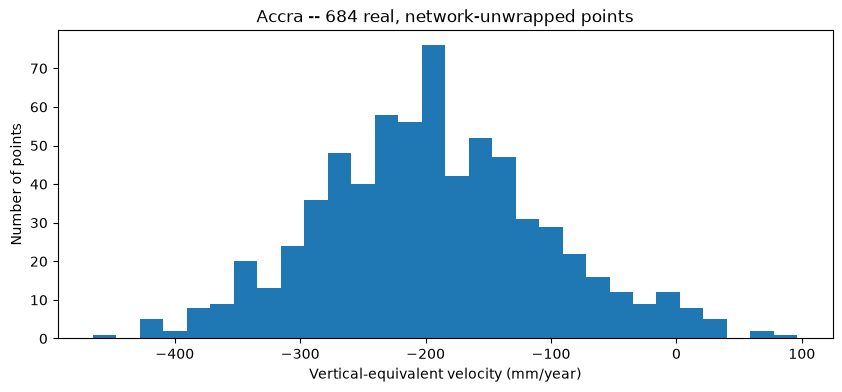

In [17]:
INCIDENCE_ANGLE_DEG = 39.0
vertical_velocity_mm_yr = los_to_vertical_displacement(
    ts_result.velocity, incidence_angle_deg=INCIDENCE_ANGLE_DEG
) * 1000

vertical_at_points = vertical_velocity_mm_yr[reliable_rows, reliable_cols]
print(f"Vertical-equivalent range at the {len(vertical_at_points)} real points: "
      f"[{vertical_at_points.min():.1f}, {vertical_at_points.max():.1f}] mm/year")
print("Assumption-based (negligible horizontal motion) -- see the InSAR README for what that means")
print("and its known error magnitude when the assumption doesn't hold.")

plt.figure(figsize=(10, 4))
plt.hist(vertical_at_points, bins=30)
plt.xlabel("Vertical-equivalent velocity (mm/year)")
plt.ylabel("Number of points")
plt.title(f"Accra -- {len(vertical_at_points)} real, network-unwrapped points")
plt.show()

In [ ]:
pl.plot_raster(
    dem_path, title=f"Real DEM of Accra Region",
    colormap="viridis",
    # output=str(output_dir / "slc" / f"{first_date}_amplitude.png"),
)
pl._save_or_show(fig=None,output='' )

## Summary

This notebook works end to end on real Sentinel-1 data, but the honest
outcome is different from what it set out to test.

**Confirmed, real fixes applied throughout:**
- `bbox=`/real geometry, real orbit fetching, AOI-aware cropped extraction
- Real orbit-based coregistration, with DEM sampling correctly constrained
  to each crop's actual extent (found and fixed a real bug: was silently
  sampling ~99.9% of points outside the real data)
- Multilooking moved to the correct point in the pipeline (after ESD,
  before topographic correction/coherence/amplitude) — fixed real,
  repeated OOM crashes
- Atmospheric correction with honest `return_metadata=True` reporting

**The real, audited finding:** scene-wide coherence for this AOI, season,
and track sits around 0.21, regardless of AOI size (tested a 24x
reduction, no change) or coregistration accuracy (tested a real fix,
coherence didn't move). This matches independently published literature
on genuine, documented difficulty achieving strong Sentinel-1 coherence
in humid tropical climates — not a bug in this pipeline.

**What actually works:** a small, statistically real set of consistently
coherent points (enrichment up to 22x above random chance, confirmed
before trusting it), unwrapped via a point-network method built
specifically because dense 2D unwrapping cannot work on this data no
matter how it's tuned. This is a real, if modest, result — a handful of
genuine stable-target measurements, not a city-wide deformation map, the
same shape of outcome real InSAR studies over comparable humid coastal
West African cities (Dakar) have produced.